# Part 4: Filtering + NUTS — A Marginal Sampler

Our motivation for using filters in the last tutorial was to do filter-based Bayesian inference of the parameters of a dynamical system -- but we didn't do that! In this tutorial, we will learn how to combine the filter-based marginal log-likelihood with `numpyro`'s inference infrastructure. 

The resulting inference methods are easily composable, which sometimes results in rather advanced methodology from simple code. In this tutorial, we will use a Taylor-extended Kalman filter over a linear Gaussian state-space model, which provides exact inference of the MLL. As a result, we are effectively performing MCMC on the marginalized posterior $p(\theta | y_{1:T})$, only. We'll conclude by talking about how composing different filters and inference algorithms can result in a flexible but powerful family of inference methods.

### Defining the Model

We again use the same LTI model as in the previous several tutorials.

In [1]:
import jax.numpy as jnp
import jax.random as jr
import numpyro
import numpyro.distributions as dist
from numpyro.infer import Predictive

import dynestyx as dsx
from dynestyx import flatten_draws
from dynestyx import DiscreteTimeSimulator, DynamicalModel

# for convenience, we can define "fixed" things in the model outside of it.
# this is not required, but it helps keep the model clean.
state_dim = 2
observation_dim = 1
control_dim = 1

# Create the known matrices B, C
B = jnp.eye(state_dim, control_dim)
C = jnp.eye(observation_dim, state_dim)

# create the initial condition as a distribution
initial_condition = dist.MultivariateNormal(jnp.zeros(state_dim), jnp.eye(state_dim))


def lti_model(sigma_obs=0.1, sigma_process=0.1, obs_times=None, obs_values=None, ctrl_times=None, ctrl_values=None, predict_times=None):
    # sample the unknown parameter
    rho = numpyro.sample("rho", dist.Uniform(-0.5, 0.5))
    A = jnp.array([[0, 0.3], [rho, -0.2]])

    # create the state evolution as a callable mapping to a distribution
    # Crucially, this depends on A, which depends on rho, which is unknown.
    # Thus, the state evolution MUST be defined within `lti_model`, not outside.
    state_evolution = lambda x, u, t_now, t_next: dist.MultivariateNormal(
        A @ x + B @ u, sigma_process**2 * jnp.eye(state_dim)
    )

    # create the observation model as a callable mapping to a distribution
    observation_model = lambda x, u, t: dist.MultivariateNormal(
        C @ x, sigma_obs**2 * jnp.eye(observation_dim)
    )

    # create the dynamical model
    dynamics = DynamicalModel(
        control_dim=control_dim,
        initial_condition=initial_condition,
        state_evolution=state_evolution,
        observation_model=observation_model,
    )

    # sample from the dynamical model
    return dsx.sample("f", dynamics, obs_times=obs_times, obs_values=obs_values, ctrl_times=ctrl_times, ctrl_values=ctrl_values, predict_times=predict_times)

### Generate synthetic data with $\rho = 0.3$.

We next generate synthetic data, using the predictive utilities discussed in tutorial 2.

In [2]:
# Generate longer trajectory: training portion + held-out future for rollout evaluation
n_train = 100
T_forecast = 100
obs_times_full = jnp.arange(0.0, n_train + T_forecast + 1, 1.0)
ctrl_times_full = obs_times_full
ctrl_values_full = jr.normal(jr.PRNGKey(0), (len(ctrl_times_full), control_dim))

# Train / test split
obs_times = obs_times_full[:n_train]
obs_times_test = obs_times_full[n_train:]
ctrl_times = ctrl_times_full[:n_train]
ctrl_times_test = ctrl_times_full[n_train:]
ctrl_values = ctrl_values_full[:n_train]
ctrl_values_test = ctrl_values_full[n_train:]

rho_true = 0.3


def make_data(sigma_obs=0.1, sigma_process=0.1):
    predictive = Predictive(
        lti_model,
        params={"rho": jnp.array(rho_true)},
        num_samples=1,
        exclude_deterministic=False,
    )
    with DiscreteTimeSimulator():
        pred = predictive(
            rng_key=jr.PRNGKey(0),
            sigma_obs=sigma_obs,
            sigma_process=sigma_process,
            predict_times=obs_times_full,
            ctrl_times=ctrl_times_full,
            ctrl_values=ctrl_values_full,
        )
    print("make_data shapes:", pred["f_times"].shape, pred["f_states"].shape, pred["f_observations"].shape)
    # Expected: (num_samples, n_sim, T, ...), with num_samples=n_sim=1 here.
    obs = pred["f_observations"][0, 0, :, :]
    states = pred["f_states"][0, 0, :, :]
    obs_values = obs[:n_train]
    obs_values_test = obs[n_train:]
    states_train = states[:n_train]
    states_test = states[n_train:]
    return obs_times, obs_values, ctrl_times, ctrl_values, obs_times_test, obs_values_test, ctrl_times_test, ctrl_values_test, states_train, states_test


obs_times, obs_values, ctrl_times, ctrl_values, obs_times_test, obs_values_test, ctrl_times_test, ctrl_values_test, states_train, states_test = make_data(sigma_obs=0.1, sigma_process=0.1)

make_data shapes: (1, 1, 201) (1, 1, 201, 2) (1, 1, 201, 1)


### Running Marginalized MCMC

To run MCMC on the marginal distribution $p(\theta | y_{1:T})$ (marginalized from $p(\theta, x_{1:T} | y_{1:T})$), we must create a data-conditioned model by wrapping in a `Filter`. On this wrapped model, inference can proceed as any normal NumPyro model would. This works because `dynestyx` internally runs the appropriate filter to obtain a marginal likelihood estimate, then accounts for the marginal likelihood with a `numpyro.factor(...)` statement. Let's see this in action, and compare to the results of using a `DiscreteTimeSimulator`, as in the [previous tutorial](02_dynestyx_discrete_intro.ipynb).

In [3]:
from dynestyx import Filter
from numpyro.infer import MCMC, NUTS
from dynestyx.inference.filters import EKFConfig
# Pseudo-marginal inference (record filtered states for latent recovery plot)
with Filter(filter_config=EKFConfig()):
    nuts_kernel = NUTS(lti_model)
    mcmc = MCMC(nuts_kernel, num_warmup=100, num_samples=100)
    mcmc.run(jr.PRNGKey(1), obs_times=obs_times, obs_values=obs_values, ctrl_times=ctrl_times, ctrl_values=ctrl_values)
    posterior_1 = mcmc.get_samples()

# Joint state + parameter inference
with DiscreteTimeSimulator():
    nuts_kernel = NUTS(lti_model)
    mcmc = MCMC(nuts_kernel, num_warmup=100, num_samples=100)
    mcmc.run(jr.PRNGKey(1), obs_times=obs_times, obs_values=obs_values, ctrl_times=ctrl_times, ctrl_values=ctrl_values)
    posterior_2 = mcmc.get_samples()

sample: 100%|██████████| 200/200 [00:00<00:00, 283.33it/s, 15 steps of size 2.57e-01. acc. prob=0.61]


### Now let's compare the recovered posteriors over $\rho$

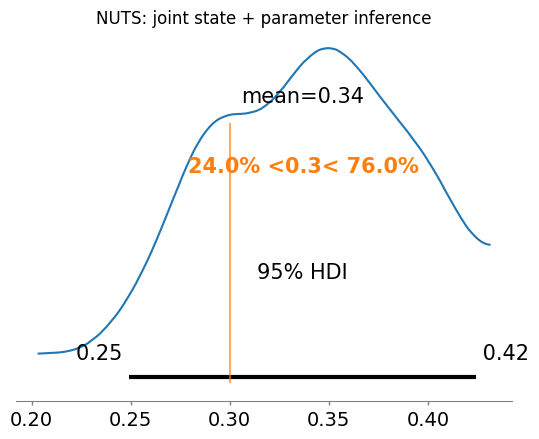

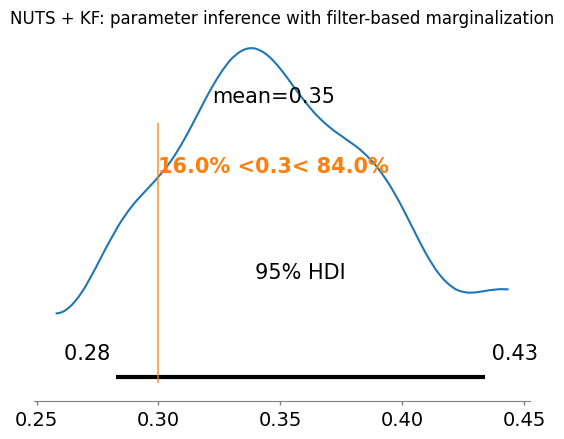

In [4]:
import arviz as az
import matplotlib.pyplot as plt

az.plot_posterior(posterior_1["rho"], hdi_prob=0.95, ref_val=rho_true)
plt.title("NUTS: joint state + parameter inference")

az.plot_posterior(posterior_2["rho"], hdi_prob=0.95, ref_val=rho_true)
plt.title("NUTS + KF: parameter inference with filter-based marginalization")
plt.show()

### Next, let's compare latent-state recovery

In both cases, we can also recover the posterior distribution over latent states. In the "joint" case, it comes explicitly from the MCMC trace; this corresponds to a "smoothing" distribution. In the "marginal" case, we store the outputs of the filter (filtered state means and covariances) along with every sample of $\rho$; this corresponds to a "filtering" distribution.

What is "smoothing" and "filtering":
- The filtering distribution at time `t`: 
    - $p(x_t \mid y_1, \dots, y_t, u_1, \dots, u_t)$,
    - only uses data up to the present
- The smoothing distribution at time `t`: 
    - $p(x_t \mid y_1, \dots, y_T, u_1, \dots, u_T)$
    - uses all available data.


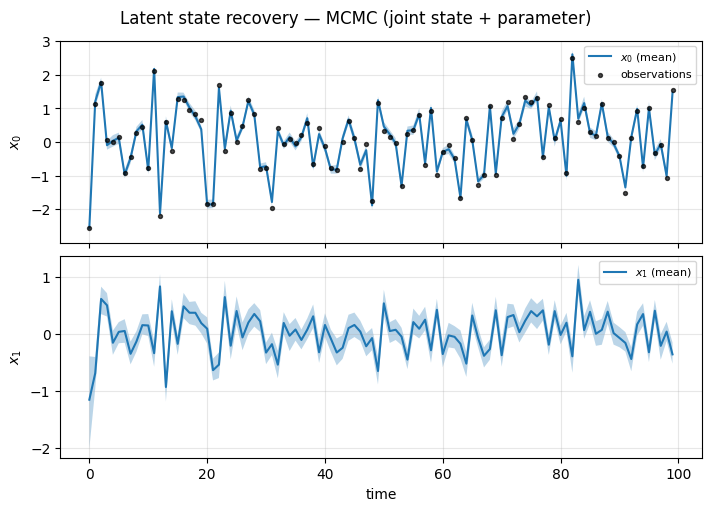

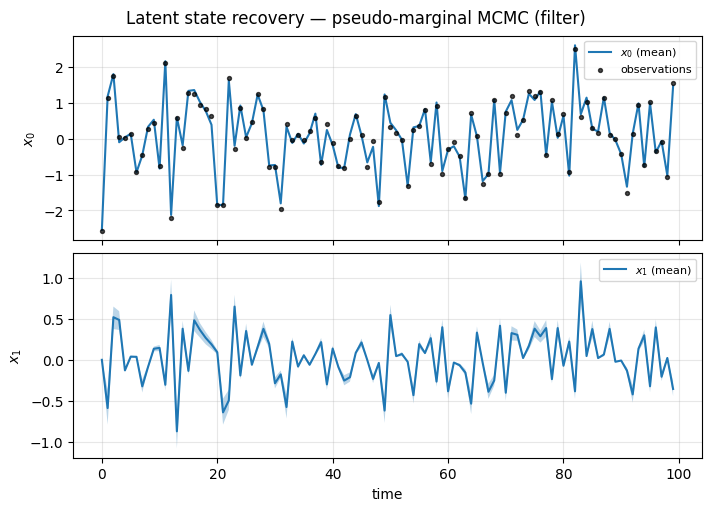

In [5]:
# Latent state recovery: 1 plot for MCMC (joint), 1 for marginal MCMC
# Observed component = first state (C = [1, 0]); overlay data as scatter there.

def plot_latent_recovery(states_samples, title, obs_times, obs_values, state_dim=2):
    """states_samples: (num_samples, T, state_dim). One figure, one subplot per state component."""
    n_comp = state_dim
    mean_states = states_samples.mean(axis=0)  # (T, state_dim)
    lo = jnp.percentile(states_samples, 2.5, axis=0)
    hi = jnp.percentile(states_samples, 97.5, axis=0)
    fig, axes = plt.subplots(
        n_comp, 1, figsize=(7, 2.5 * n_comp), sharex=True, constrained_layout=True
    )
    if n_comp == 1:
        axes = [axes]
    for i in range(n_comp):
        ax = axes[i]
        ax.fill_between(obs_times, lo[:, i], hi[:, i], alpha=0.3)
        ax.plot(obs_times, mean_states[:, i], label=f"$x_{i}$ (mean)")
        if i == 0:  # observed component: overlay data
            ax.scatter(
                obs_times,
                obs_values,
                s=8,
                alpha=0.7,
                color="k",
                label="observations",
                zorder=3,
            )
        ax.set_ylabel(f"$x_{i}$")
        ax.legend(loc="upper right", fontsize=8)
        ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel("time")
    fig.suptitle(title)
    plt.show()


# MCMC (joint): posterior over states from simulator.
# f_states has shape (num_samples, n_sim, T, state_dim); flatten_draws merges the draw axes.
states_joint = flatten_draws(posterior_2["f_states"])
plot_latent_recovery(
    states_joint,
    "Latent state recovery — MCMC (joint state + parameter)",
    obs_times,
    obs_values,
    state_dim=state_dim,
)

# Pseudo-marginal MCMC: filtered state means from KF (one per rho sample).
# f_filtered_states_mean has shape (num_samples, T, state_dim) — no n_sim axis from filter.
plot_latent_recovery(
    posterior_1["f_filtered_states_mean"],
    "Latent state recovery — pseudo-marginal MCMC (filter)",
    obs_times,
    obs_values,
    state_dim=state_dim,
)

**Performance notes:**
- **Why is Predictive slower than MCMC (even with num_samples=1)?** MCMC runs the **Filter only**—each NUTS step evaluates the marginal log-likelihood via one filter pass (cheap matrix ops). Predictive runs **Filter + Simulator**: one filter pass, then a **segmented rollout**. For each filtered time (0..99), the simulator runs a segment; when `predict_times` are all in the future (e.g. 100..200), only the last segment has any predict_times, but we still run **101 full simulator calls** (1 initial + 100 filtered). Each call simulates the full `predict_times` array, so Predictive does ~101× the simulator work of a single filter pass.
- **num_samples > 1:** NumPyro's `Predictive` uses `lax.map` internally, which is very slow (e.g. 4+ minutes for 2 samples vs ~16 s for 1). Use `_predictive_rollout_sequential` instead—it runs `Predictive(num_samples=1)` in a Python loop and scales linearly (~16 s per sample).
- **Shape convention:** simulator outputs always include a leading `n_simulations` axis (size 1 by default). Under `Predictive`, there is also a leading `num_samples` axis. In plotting cells below, draw axes are flattened explicitly with `reshape`.

### Predictive rollout

To evaluate **rollout quality**—forecasts into the held-out test period—use **Filter + Simulator** with `predict_times`. The filter conditions on `obs_times` / `obs_values`; the simulator rolls out trajectories at `predict_times` (train + test), producing `f_predicted_states` and `f_predicted_observations`. With `n_simulations > 1`, you get multiple trajectories for uncertainty bands.

rollout shapes: (2, 20, 101, 2) (2, 20, 101) (2, 100, 2)


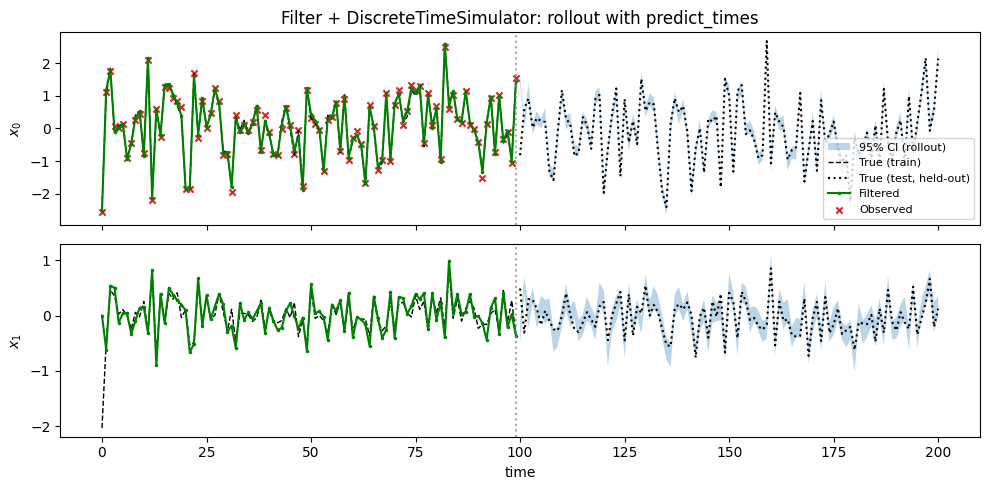

In [6]:
from numpyro.infer import Predictive

from dynestyx import Filter, flatten_draws
from dynestyx.inference.filter_configs import EKFConfig


# Use posterior mean for rollout
rho_post_mean = jnp.mean(posterior_2["rho"])
n_sim = 20
num_samples = 2  # Use sequential loop to avoid lax.map overhead

predictive = Predictive(
    lti_model,
    params={"rho": jnp.array(rho_post_mean)},
    num_samples=num_samples,
    exclude_deterministic=False,
)

with DiscreteTimeSimulator(n_simulations=n_sim):
    with Filter(filter_config=EKFConfig(record_filtered_states_mean=True, filter_source="cuthbert")):
        samples = predictive(
            jr.PRNGKey(99),
            obs_times=obs_times,
            obs_values=obs_values,
            ctrl_times=ctrl_times_full,
            ctrl_values=ctrl_values_full,
            predict_times=obs_times_test,
        )

pred_states = jnp.asarray(samples["f_predicted_states"])  # (num_samples, n_sim, T_pred, state_dim)
pred_times_arr = jnp.asarray(samples["f_predicted_times"])  # (num_samples, n_sim, T_pred)
filtered_means = jnp.asarray(samples["f_filtered_states_mean"])  # (num_samples, T_train, state_dim)

print("rollout shapes:", pred_states.shape, pred_times_arr.shape, filtered_means.shape)

# flatten_draws merges (num_samples, n_sim, T, D) → (num_samples*n_sim, T, D).
# Filter outputs like f_filtered_states_mean are already (num_samples, T, D) with no n_sim axis.
pred_draws = flatten_draws(pred_states)
pred_t = flatten_draws(pred_times_arr)[0]
filtered_med = jnp.percentile(filtered_means, 50.0, axis=0)

# Plot: true states, filtered means, observations, predicted CI
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
lo = jnp.percentile(pred_draws, 2.5, axis=0)
hi = jnp.percentile(pred_draws, 97.5, axis=0)
for i, ax in enumerate(axes):
    ax.fill_between(pred_t, lo[:, i], hi[:, i], alpha=0.3, label="95% CI (rollout)")
    ax.plot(obs_times, states_train[:, i], "k--", label="True (train)", lw=1)
    ax.plot(obs_times_test, states_test[:, i], "k:", lw=1.5, label="True (test, held-out)")
    ax.plot(obs_times, filtered_med[:, i], "g.-", markersize=3, label="Filtered")
    if i == 0:
        ax.scatter(obs_times, obs_values if obs_values.ndim == 1 else obs_values[:, 0], color="C3", marker="x", s=20, label="Observed")
        # ax.scatter(obs_times_test, obs_values_test if obs_values_test.ndim == 1 else obs_values_test[:, 0], color="C4", marker="+", s=30, label="Test (held-out)")
        ax.legend(loc="lower right", fontsize=8)
    ax.set_ylabel(f"$x_{i}$")
    ax.axvline(obs_times[-1], color="gray", linestyle=":", alpha=0.7)
axes[0].set_title("Filter + DiscreteTimeSimulator: rollout with predict_times")
axes[-1].set_xlabel("time")
plt.tight_layout()
plt.show()

### Filtering was slower... so why bother?

In harder problems (e.g., non-linear, non-gaussian, etc.), sometimes joint MCMC over parameters + states doesn't work at all (it fails to even identify the region of highest probability)!
It's worth trying both approaches and comparing. Fortunately we make that easy; just swap `with Filter()` for `with DiscreteTimeSimulator()` and compare!

### Composing Different Inference Methods and Filters

The pattern we just used --- creating a data-conditioned model with a filter, then performing marginal inference with MCMC --- is easily generalized to other inference methods or filters. In fact, we recover lots of interesting filters from the literature this way! As a few examples:

- Using a particle filter with MCMC, we obtain [particle MCMC](https://academic.oup.com/jrsssb/article-abstract/72/3/269/7076437). This family of methods is known to be expensive but unbiased in a very wide range of scenarios, with applicability to nearly arbitrary state-space models. 
  - Depending on the inference method, we could be uncovering various different sub-methods; for example, using `HMC`, we obtain [particle Hamiltonian Monte Carlo](https://arxiv.org/abs/2504.09875). We can obtain the reduced-variance estimates therein by using a marginal particle filter.
- Using an ensemble Kalman filter (EnKF) as the filter, we obtain [ensemble MCMC](https://projecteuclid.org/journals/bayesian-analysis/volume-17/issue-1/Ensemble-MCMC--Accelerating-Pseudo-Marginal-MCMC-for-State-Space/10.1214/20-BA1251.full). This is biased but can be extremely fast.

In the coming tutorials, we will also step towards extremely simple implementations of variational sequential Monte Carlo methods by replacing the outer inference method with SVI!

**Next:** [Part 5 — SVI and warming up NUTS](../05_svi/)